# InSight Seismic Data (VBB)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import obspy
from obspy.signal.detrend import polynomial
from obspy import read, read_inventory
from obspy.signal.rotate import rotate2zne
from obspy.signal.filter import bandpass
from obspy.clients.fdsn import Client
import warnings
warnings.simplefilter('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = 10, 5

In [2]:
path_dataless='./instrumental_resp/dataless.XB.ELYSE.seed';
fdsn_client = Client("IRIS")
net_code = "XB" # Fill in the two-character network code for InSight
sta_code = "ELYSE"
Date_s=20220504;
out_csv='./'+str(Date_s)+'_ACC_original.csv'
# Origin time of S1222a (2022-05-04-23:23:07, Kawamura et al., 2022)
starttime = obspy.UTCDateTime(2022, 5, 4, 23, 13, 7); 
endtime = obspy.UTCDateTime(2022, 5, 5, 0, 53, 7);
down_sp=20; #down to X Hz

## Download data

In [3]:
st_U = fdsn_client.get_waveforms(network=net_code, station=sta_code, location="02", channel="BHU", starttime=starttime, endtime=endtime, attach_response=True)
st_V = fdsn_client.get_waveforms(network=net_code, station=sta_code, location="02", channel="BHV", starttime=starttime, endtime=endtime, attach_response=True)
st_W = fdsn_client.get_waveforms(network=net_code, station=sta_code, location="02", channel="BHW", starttime=starttime, endtime=endtime, attach_response=True)
## Trimming
t_U_st=st_U[0].stats.starttime; t_U_end=st_U[0].stats.endtime;
t_V_st=st_V[0].stats.starttime; t_V_end=st_V[0].stats.endtime;
t_W_st=st_W[0].stats.starttime; t_W_end=st_W[0].stats.endtime;
min_date_max=max(t_U_st, t_V_st, t_W_st);
max_date_min=min(t_U_end, t_V_end, t_W_end);
## Time-series
st_U.trim(starttime=min_date_max, endtime=max_date_min);
st_V.trim(starttime=min_date_max, endtime=max_date_min);
st_W.trim(starttime=min_date_max, endtime=max_date_min);

## Detrend

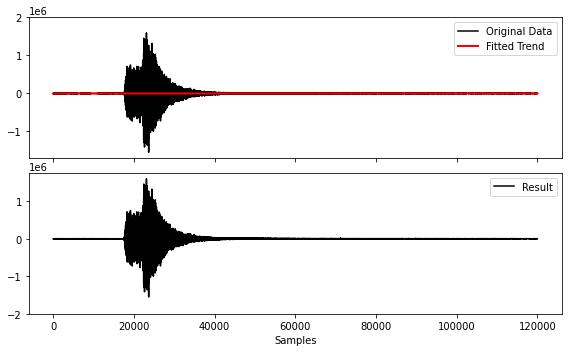

In [4]:
st_U[0].data=polynomial(st_U[0].data, order=12, plot=True)  
st_V[0].data=polynomial(st_V[0].data, order=12, plot=False)  
st_W[0].data=polynomial(st_W[0].data, order=12, plot=False)  

## Remove instrumental response

In [5]:
inv=read_inventory(path_dataless);
pre_filt = [0.003, 0.005, 9.5, 10];
st_U[0].remove_response(inventory=inv,output="VEL", pre_filt=pre_filt, zero_mean=True,taper=True,taper_fraction=0.05)
st_V[0].remove_response(inventory=inv,output="VEL", pre_filt=pre_filt, zero_mean=True,taper=True,taper_fraction=0.05)
st_W[0].remove_response(inventory=inv,output="VEL", pre_filt=pre_filt, zero_mean=True,taper=True,taper_fraction=0.05)
t_vbb = np.linspace(0, st_U[0].data.size/st_U[0].stats.sampling_rate, st_U[0].data.size)

## Rotation (UVW => ZNE)

In [6]:
U_azi =inv.select(channel=st_U[0].stats.channel, station=st_U[0].stats.station)[0][0][0].azimuth
U_dip =inv.select(channel=st_U[0].stats.channel, station=st_U[0].stats.station)[0][0][0].dip
V_azi =inv.select(channel=st_V[0].stats.channel, station=st_V[0].stats.station)[0][0][0].azimuth
V_dip =inv.select(channel=st_V[0].stats.channel, station=st_V[0].stats.station)[0][0][0].dip
W_azi =inv.select(channel=st_W[0].stats.channel, station=st_W[0].stats.station)[0][0][0].azimuth
W_dip =inv.select(channel=st_W[0].stats.channel, station=st_W[0].stats.station)[0][0][0].dip
print("U azimuth =" ,U_azi); print("U dip =" ,U_dip)
print("V azimuth =" ,V_azi); print("V dip =" ,V_dip)
print("W azimuth =" ,W_azi); print("W dip =" ,W_dip)
print(st_U[0].data.size); print(st_V[0].data.size); print(st_W[0].data.size);
Z, N, E=rotate2zne(st_U[0].data, U_azi, U_dip, st_V[0].data, V_azi, V_dip, st_W[0].data, W_azi, W_dip)

U azimuth = 135.1
U dip = -29.4
V azimuth = 15.0
V dip = -29.2
W azimuth = 255.0
W dip = -29.7
120000
120000
120000


## Bandpass filter

In [7]:
Z_bp=bandpass(Z, 0.1, 1.0, st_U[0].stats.sampling_rate, corners=4, zerophase=True)
N_bp=bandpass(N, 0.1, 1.0, st_U[0].stats.sampling_rate, corners=4, zerophase=True)
E_bp=bandpass(E, 0.1, 1.0, st_U[0].stats.sampling_rate, corners=4, zerophase=True)

## Plot

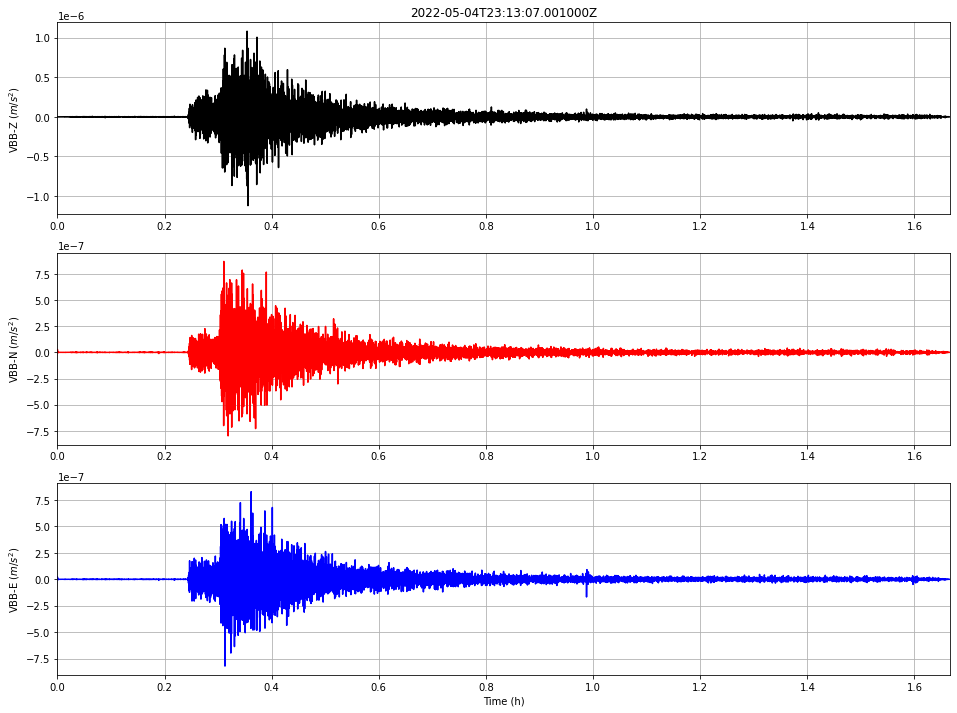

In [8]:
fig = plt.figure(figsize=(16,12))
ax1 = fig.add_subplot(3, 1, 1)
plt.plot(t_vbb/3600, Z_bp,'k-'); plt.ylabel("VBB-Z ($m/s^2$)"); #plt.xlim([500, 2500])
plt.title(t_U_st)
plt.grid(); plt.xlim([min(t_vbb/3600), max(t_vbb/3600)])
ax2 = fig.add_subplot(3, 1, 2)
plt.plot(t_vbb/3600, N_bp,'r-'); plt.ylabel("VBB-N ($m/s^2$)"); #plt.xlim([500, 2500])
plt.grid(); plt.xlim([min(t_vbb/3600), max(t_vbb/3600)])
ax3 = fig.add_subplot(3, 1, 3)
plt.plot(t_vbb/3600, E_bp,'b-'); plt.ylabel("VBB-E ($m/s^2$)"); plt.xlabel("Time (h)"); #plt.xlim([500, 2500])
plt.grid(); plt.xlim([min(t_vbb/3600), max(t_vbb/3600)])
plt.show()